**************** Decision Tree Implement from scratch ********************

In [1]:
import numpy as np
from collections import Counter
from graphviz import Digraph

In [2]:
class Node():
    """
    A class representing a node in a decision tree.
    """

    def __init__(self, feature=None, threshold=None, left=None, right=None, entropy=None, gain=None, value=None, name=None):
        """
        Initializes a new instance of the Node class.

        Args:
            feature: The feature used for splitting at this node. Defaults to None.
            threshold: The threshold used for splitting at this node. Defaults to None.
            left: The left child node. Defaults to None.
            right: The right child node. Defaults to None.
            gain: The gain of the split. Defaults to None.
            value: map of value => count.
        """
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.entropy = entropy
        self.gain = gain
        self.value = value
        self.name = name


In [63]:
def single_prediction(row, node):
    """
    Predict a single y for row.

    Args:
    x (ndarray): a single row.

    returns y: a single prediction
    """
    if node.left is None or node.right is None:
        return node.value
    if row[node.feature] <= node.threshold:
        return single_prediction(row, node.left)
    else:
        return single_prediction(row, node.right)

def counterAsStr(counters):
    aggregator = []
    for (key, value) in counters.items() :
        aggregator.append(f"{str(key)}: {value}")
    return "{ " + ", ".join(aggregator) + " }"

class DecisionTree():
    """
    A decision tree classifier for binary classification problems.
    """

    def __init__(self, min_samples=2, max_depth=2, min_information_gain=0.00001, enable_debug=False):
        """
        Constructor for DecisionTree class.

        Parameters:
            min_samples (int): Minimum number of samples required to split an internal node.
            max_depth (int): Maximum depth of the decision tree.
        """
        self.min_samples = min_samples
        self.max_depth = max_depth
        self.min_information_gain = min_information_gain
        self.enable_debug = enable_debug
        
    def split_data(self, dataset, feature, threshold):
        """
        Splits the given dataset into two datasets based on the given feature and threshold.

        Parameters:
            dataset (ndarray): Input dataset.
            feature (int): Index of the feature to be split on.
            threshold (float): Threshold value to split the feature on.

        Returns:
            left_dataset (ndarray): Subset of the dataset with values less than or equal to the threshold.
            right_dataset (ndarray): Subset of the dataset with values greater than the threshold.
        """
        # Create empty arrays to store the left and right datasets
        left_dataset = []
        right_dataset = []
        
        # Loop over each row in the dataset and split based on the given feature and threshold
        for row in dataset:
            if row[feature] <= threshold:
                left_dataset.append(row)
            else:
                right_dataset.append(row)

        # Convert the left and right datasets to numpy arrays and return
        left_dataset = np.array(left_dataset)
        right_dataset = np.array(right_dataset)
        return left_dataset, right_dataset

    def entropy(self, y):
        """
        Computes the entropy of the given label values.

        Parameters:
            y (ndarray): Input label values.

        Returns:
            entropy (float): Entropy of the given label values.
        """

        entropy = 0
        total_elements = len(y)
        for value in Counter(y).values():
            p_x = value / total_elements
            entropy += p_x * np.log2(p_x)
        entropy = -1 * entropy
        return entropy
            
    def information_gain(self, parent, left, right):
        """
        Computes the information gain from splitting the parent dataset into two datasets.

        Parameters:
            parent (ndarray): Input parent dataset.
            left (ndarray): Subset of the parent dataset after split on a feature.
            right (ndarray): Subset of the parent dataset after split on a feature.

        Returns:
            information_gain (float): Information gain of the split.
        """
        information_gain = 0
        len_p = len(parent)
        entropy_p = self.entropy(parent)
        # information_gain = entropy(parent) - sum(len(child)/len(parent)*entropy(child))
        #                  = entropy(parent) + sum(-1 * len(child)*entropy(child)/len(parent))
        information_gain = entropy_p;
        information_gain -= len(left) * self.entropy(left) / len_p
        information_gain -= len(right) * self.entropy(right) / len_p
        return information_gain

    def debug(self, string):
        if (self.enable_debug):
            print(string)

    def best_split(self, dataset, name):
        """
        Finds the best split for the given dataset.

        Args:
        dataset (ndarray): The dataset to split.

        Returns:
        tuple: a tuple with left and right datasets, and the node.
        """
        self.debug(f"{name}: Finding a split")
        num_features = dataset.shape[1]-1
        best_split_gain=-1
        retval = ((), (), Node(None, None, None, None, None, None, counterAsStr(Counter(dataset[:, -1])), name))
        for feature_index in range(num_features):
            self.debug(f"Checking Feature {feature_index}")
            feature_values = dataset[:,feature_index]
            for threshold in Counter(feature_values):
                self.debug(f"Checking threshold {threshold}")
                # get left and right datasets
                left_dataset, right_dataset = self.split_data(dataset, feature_index, threshold)
                # check if either datasets is empty
                if len(left_dataset) >= self.min_samples and len(right_dataset) >= self.min_samples:
                    # f(x) => y. By convention, y is the last column.
                    y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
                    # compute information gain based on the y values
                    information_gain = self.information_gain(y, left_y, right_y)
                    # update the best split if conditions are met
                    if information_gain > best_split_gain and information_gain >= self.min_information_gain:
                        self.debug(f"found a split!")
                        retval = (left_dataset, right_dataset, Node(feature_index, threshold, None, None, self.entropy(y), information_gain, None, name))
                    else:
                        self.debug(f"the split wasn't good enough")
                else:
                    self.debug(f"either left or right is too small")

        return retval

    def build_tree(self, dot, dataset, current_depth=0, name="root"):
        """
        Recursively builds a decision tree from the given dataset.
        Args:
        dataset (ndarray): The dataset to build the tree from.
        current_depth (int): The current depth of the tree.

        Returns:
        Node: The root node of the built decision tree.
        """
        # if we've exceeded our depth, the parent is the leaf.
        if current_depth > self.max_depth:
            return None
        (left_dataset, right_dataset, new_node) = self.best_split(dataset, name)
        # if left or right is None, we can't split any further, this is a leaf.
        if not (len(left_dataset) and len(right_dataset)):
            dot.node(name=name, label=new_node.value)
            return new_node
        new_depth = current_depth + 1
        new_node.left = self.build_tree(dot, left_dataset, new_depth, name + ".l")
        new_node.right = self.build_tree(dot, right_dataset, new_depth, name + ".r")

        dot.node(name=name,
                 label=f"Feature {new_node.feature}\nEntropy: {new_node.entropy}\nIG: {new_node.gain}")
        dot.edge(tail_name=name, head_name=new_node.left.name, label=f"<= {new_node.threshold}")
        dot.edge(tail_name=name, head_name=new_node.right.name, label=f"> {new_node.threshold}")
        return new_node

    def fit(self, X, y, dot = None):
        """
        Builds and fits the decision tree to the given X and y values.

        Args:
        X (ndarray): The feature matrix.
        y (ndarray): The target values.
        """
        dataset = np.concatenate((X, y), axis=1)  
        self.root = self.build_tree(dot, dataset)
        return self

    def predict(self, X):
        """
        Predicts the class labels for each instance in the feature matrix X.

        Args:
        X (ndarray): The feature matrix to make predictions for.

        Returns:
        list: A list of predicted class labels.
        """
        return np.vectorize(single_prediction, excluded={1})(X, self.root)


In [66]:
dot = Digraph()

data = np.loadtxt("data/rtg_A.csv", delimiter=",", dtype=np.dtype('>i4'), encoding="utf-8", skiprows=1)

In [67]:
tree = DecisionTree(min_samples=2, max_depth=10, min_information_gain=0.00001)
tree.build_tree(dot, data)

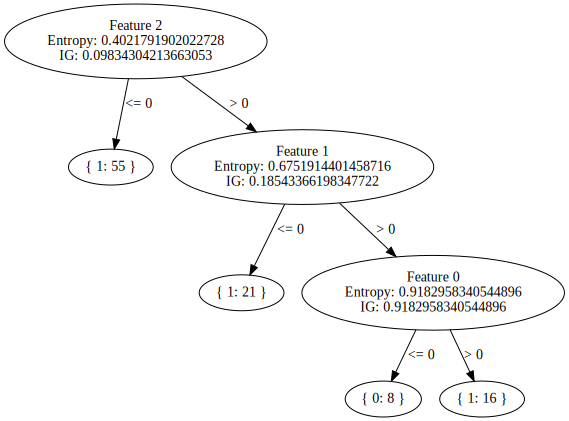

In [68]:
dot